|S.No| BITS ID | Name | Contribution |
|:-:| --- | --- | :---: |
|1| 2024AA05738 | Akshatha D | 100 |
|2| 2024AB05155| Dinesh Singh | 100 |
|3| 2024AA05181 | Jagadi Shruti Chanabasappa | 100 |
|4| 2024AA05534 | K Pranav Ram | 100 |
|5| 2024AA05748 | Kedar Ashutosh Anil | 100 |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import cifar10
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
tf.random.set_seed(42)
np.random.seed(42)
RANDOM_STATE = 42

### Task 1: PCA (95% energy) + Logistic Regression + ROC curves

Dataset: 60000 images, each 32x32 (grayscale)
Train: 42000 images, Test: 18000 images
[full] Components to retain 95% energy: K = 160


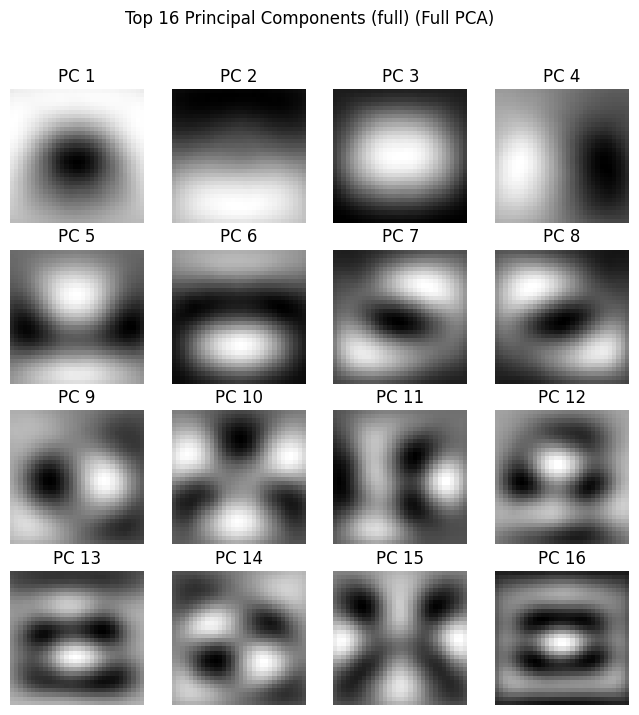

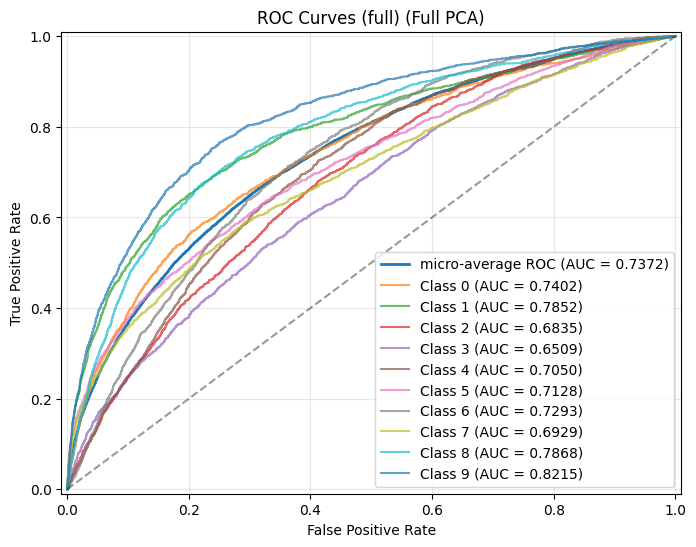

[randomized] Components to retain 95% energy: K = 160


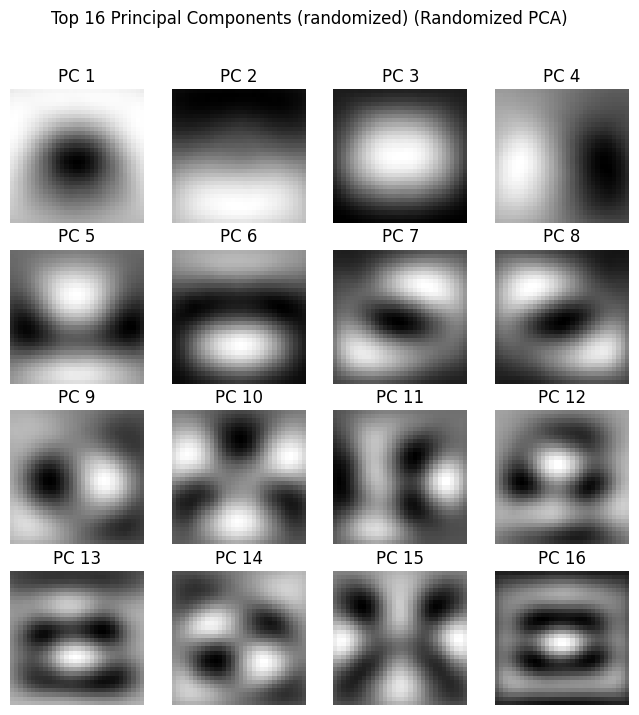

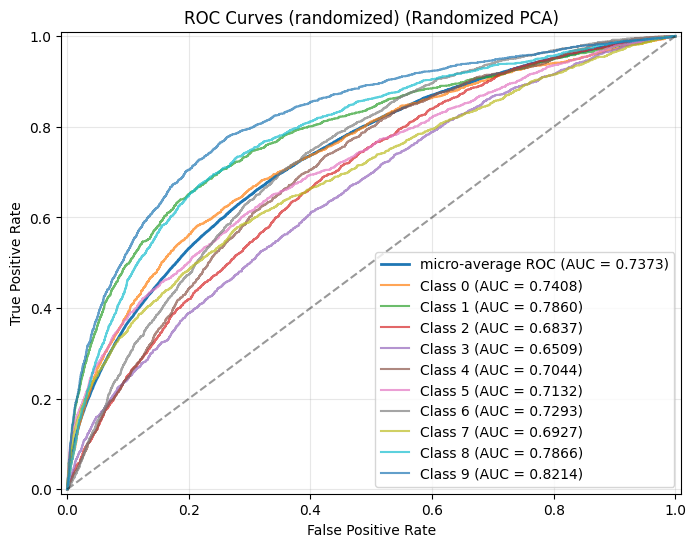

Comparison:
Exact PCA: K = 160, micro AUC = 0.7372
Randomized PCA: K = 160, micro AUC = 0.7373


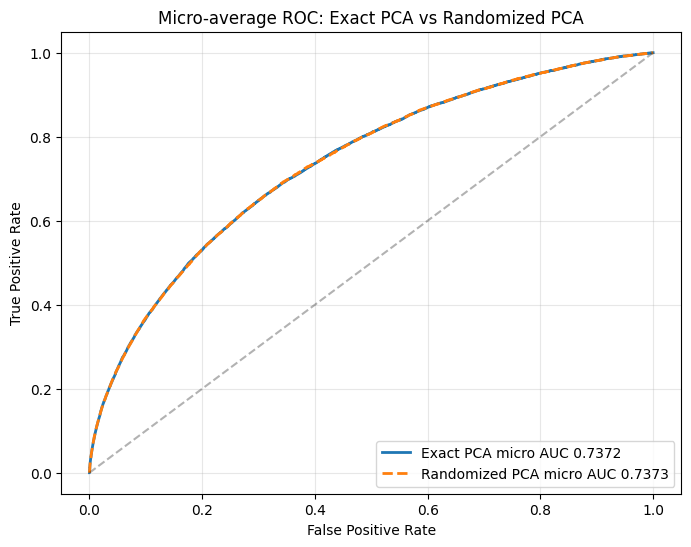

In [2]:
# Load CIFAR-10 Dataset
(x_train_full, y_train_full), (x_test_full, y_test_full) = cifar10.load_data()

# Combine to form single dataset which can be split 
X = np.vstack([x_train_full, x_test_full]) 
y = np.vstack([y_train_full, y_test_full]).ravel()

# Convert RGB to grayscale
def rgb2gray(images):
    return np.mean(images, axis=-1, keepdims=True)

X_gray = rgb2gray(X)
n_samples, h, w, _ = X_gray.shape
print(f"Dataset: {n_samples} images, each {h}x{w} (grayscale)")

# Flatten images for PCA/logistic regression
X_flat = X_gray.reshape(n_samples, -1)  # (60000, 1024)

#Train/test split 70:30
X_train, X_test, y_train, y_test = train_test_split(
    X_flat, y, train_size=0.70, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {X_train.shape[0]} images, Test: {X_test.shape[0]} images")

# Standardize features before PCA
scaler = StandardScaler(with_mean=True, with_std=True)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Function to run PCA variant, train logistic, compute ROC curves
def run_pca_and_eval(X_tr, X_te, y_tr, y_te, pca_solver='full', title_suffix=''):
    # Fit PCA on training, top K components for 95% energy
    pca_full = PCA(svd_solver=pca_solver, random_state=RANDOM_STATE)
    pca_full.fit(X_tr)
    cum_energy = np.cumsum(pca_full.explained_variance_ratio_)
    K = np.searchsorted(cum_energy, 0.95) + 1  # +1 because searchsorted returns index
    print(f"[{pca_solver}] Components to retain 95% energy: K = {K}")

    # Fit PCA with top K components
    pca_k = PCA(n_components=K, svd_solver=pca_solver, random_state=RANDOM_STATE)
    X_tr_pca = pca_k.fit_transform(X_tr)
    X_te_pca = pca_k.transform(X_te)

    # visualize top principal components (eigenvectors) as images
    comps = pca_k.components_
    num_show = min(16, K)
    _, axes = plt.subplots(4, 4, figsize=(8, 8))
    axes = axes.ravel()
    for i in range(num_show):
        comp_img = comps[i].reshape(h, w)
        # normalize for display
        comp_img = (comp_img - comp_img.min()) / (comp_img.max() - comp_img.min() + 1e-12)
        axes[i].imshow(comp_img, cmap='gray')
        axes[i].set_title(f"PC {i+1}")
        axes[i].axis('off')
    for j in range(num_show, 16):
        axes[j].axis('off')
    plt.suptitle(f"Top {num_show} Principal Components ({pca_solver}) {title_suffix}")
    plt.show()

    # Train logistic regression classifier on PCA features
    clf = LogisticRegression(
        multi_class='multinomial', solver='saga', max_iter=2000, random_state=RANDOM_STATE, n_jobs=-1
    )
    clf.fit(X_tr_pca, y_tr)

    # Compute probabilities on test set and ROC curves
    n_classes = len(np.unique(y_tr))
    y_test_binarized = label_binarize(y_te, classes=np.arange(n_classes))
    y_score = clf.predict_proba(X_te_pca)

    # Compute ROC for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Compute micro-average ROC curve and AUC
    fpr["micro"], tpr["micro"], _ = roc_curve(y_test_binarized.ravel(), y_score.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    # Plot micro-average ROC per-class 
    plt.figure(figsize=(8, 6))
    plt.plot(fpr["micro"], tpr["micro"], label=f"micro-average ROC (AUC = {roc_auc['micro']:.4f})", linewidth=2)
    # Plot curves of individual classes
    for i in roc_auc.keys():
        if i=='micro':
            continue
        plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.4f})", alpha=0.7)
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.4)
    plt.xlim([-0.01, 1.01])
    plt.ylim([-0.01, 1.01])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curves ({pca_solver}) {title_suffix}")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

    results = {
        "K": K,
        "pca_model": pca_k,
        "clf": clf,
        "fpr": fpr,
        "tpr": tpr,
        "roc_auc": roc_auc,
        "X_tr_pca": X_tr_pca,
        "X_te_pca": X_te_pca,
    }
    return results

# Run full PCA
results_full = run_pca_and_eval(X_train_scaled, X_test_scaled, y_train, y_test, pca_solver='full', title_suffix='(Full PCA)')

# Run randomized PCA
results_rand = run_pca_and_eval(X_train_scaled, X_test_scaled, y_train, y_test, pca_solver='randomized', title_suffix='(Randomized PCA)')

# Print comparison of K and micro AUC
print("Comparison:")
print(f"Exact PCA: K = {results_full['K']}, micro AUC = {results_full['roc_auc']['micro']:.4f}")
print(f"Randomized PCA: K = {results_rand['K']}, micro AUC = {results_rand['roc_auc']['micro']:.4f}")

# Plot both micro ROC curves on the same figure for direct comparison
plt.figure(figsize=(8,6))
plt.plot(results_full['fpr']['micro'], results_full['tpr']['micro'], label=f"Exact PCA micro AUC {results_full['roc_auc']['micro']:.4f}", linewidth=2)
plt.plot(results_rand['fpr']['micro'], results_rand['tpr']['micro'], label=f"Randomized PCA micro AUC {results_rand['roc_auc']['micro']:.4f}", linewidth=2, linestyle='--')
plt.plot([0,1],[0,1],'k--', alpha=0.3)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Micro-average ROC: Exact PCA vs Randomized PCA")
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()


### Task 2: Single-layer linear autoencoder (K encoder nodes) with tied weights and unit-magnitude weight vectors


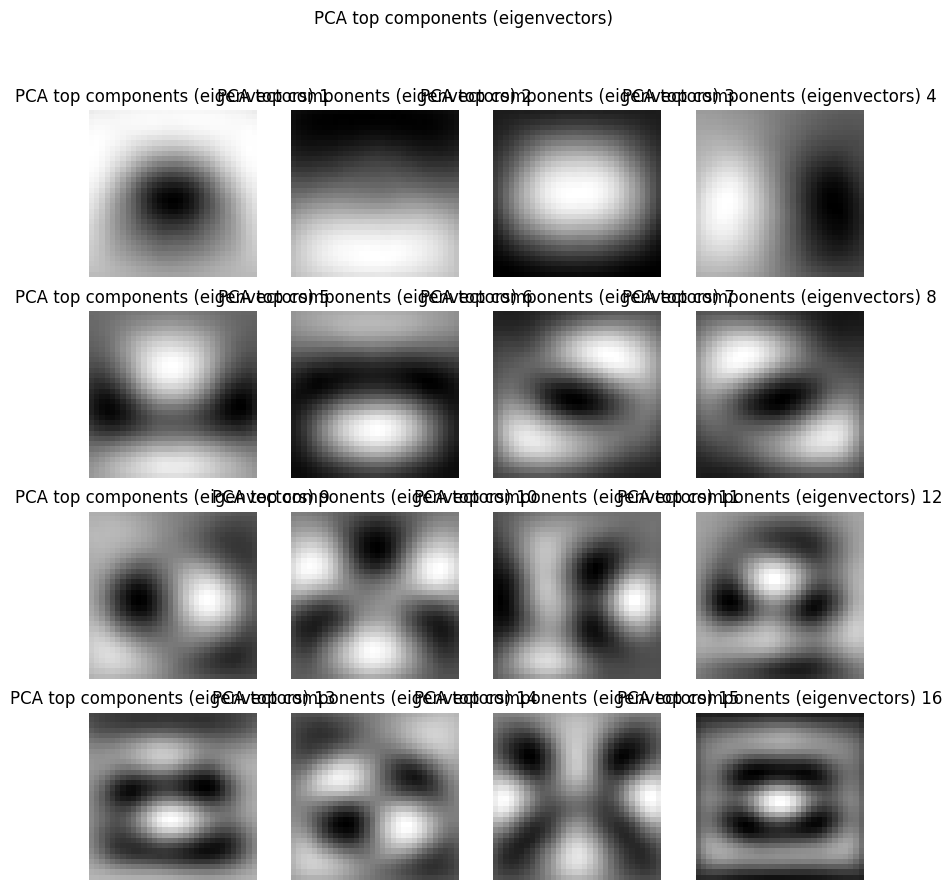

Building linear autoencoder with input_dim=1024, latent K=160


I0000 00:00:1765098221.534824    1536 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5580 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Start training linear autoencoder...


2025-12-07 09:03:44.143012: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 1/50 - train MSE: 0.227718


...

Epoch 10/50 - train MSE: 0.052516
Epoch 15/50 - train MSE: 0.052261


2025-12-07 09:03:48.590357: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 20/50 - train MSE: 0.052292
Epoch 25/50 - train MSE: 0.052236
Epoch 30/50 - train MSE: 0.052320


2025-12-07 09:03:53.543465: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 35/50 - train MSE: 0.052368
Epoch 40/50 - train MSE: 0.052351
Epoch 45/50 - train MSE: 0.052295
Epoch 50/50 - train MSE: 0.052396
Training finished.
Autoencoder reconstruction MSE on test set: 0.052593
W_components shape (for display): (160, 1024)


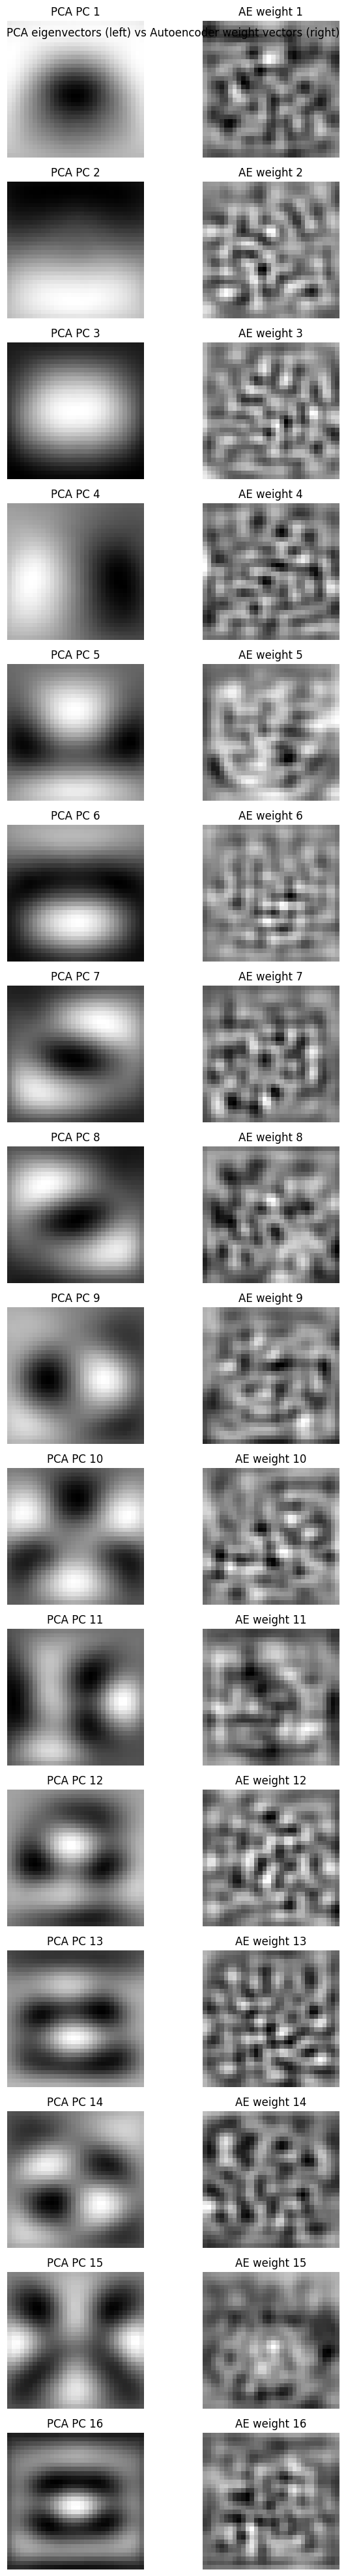

Cosine similarity PCA_1 vs AE_1: 0.0000
Cosine similarity PCA_2 vs AE_2: 0.0004
Cosine similarity PCA_3 vs AE_3: -0.0006
Cosine similarity PCA_4 vs AE_4: -0.0010
Cosine similarity PCA_5 vs AE_5: 0.1370
Cosine similarity PCA_6 vs AE_6: 0.0024
Cosine similarity PCA_7 vs AE_7: 0.0087
Cosine similarity PCA_8 vs AE_8: 0.0611
Cosine similarity PCA_9 vs AE_9: -0.1397
Cosine similarity PCA_10 vs AE_10: 0.0213
Cosine similarity PCA_11 vs AE_11: -0.2401
Cosine similarity PCA_12 vs AE_12: 0.0094
Cosine similarity PCA_13 vs AE_13: 0.0040
Cosine similarity PCA_14 vs AE_14: 0.0150
Cosine similarity PCA_15 vs AE_15: -0.2334
Cosine similarity PCA_16 vs AE_16: -0.0258
Average cosine similarity (top shown): -0.02383666424018608


In [3]:
# PCA from task 1
pca_k = results_full['pca_model']
K_components = results_full['K']
M_display = min(16, K_components)

def show_components(components, title, n_show=M_display, img_shape=(h, w)):
    n_show = min(n_show, components.shape[0])
    cols = 4
    rows = int(np.ceil(n_show / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols*2.5, rows*2.5))
    axes = axes.ravel()
    for i in range(len(axes)):
        axes[i].axis('off')
    for i in range(n_show):
        comp = components[i].reshape(img_shape)
        # normalize for display
        comp = (comp - comp.min()) / (comp.max() - comp.min() + 1e-12)
        axes[i].imshow(comp, cmap='gray')
        axes[i].set_title(f"{title} {i+1}")
    plt.suptitle(title)
    plt.show()

show_components(pca_k.components_, "PCA top components (eigenvectors)")

# Build linear autoencoder with tied weights: encoder W (input_dim -> K), decoder uses W^T
input_dim = X_train_scaled.shape[1]
K_latent = K_components  # use same latent dimension as PCA

print(f"Building linear autoencoder with input_dim={input_dim}, latent K={K_latent}")


class TiedLinearAutoencoder(keras.Model):
    def __init__(self, input_dim, latent_dim):
        super().__init__()
        w_init = tf.random.normal(shape=(input_dim, latent_dim), stddev=0.01, seed=RANDOM_STATE)
        self.W = tf.Variable(w_init, trainable=True, dtype=tf.float32, name="W_tied")
        self.input_dim = input_dim
        self.latent_dim = latent_dim

    def call(self, inputs):
        # inputs: (batch, input_dim)
        # encoder: z = X @ W  -> shape (batch, latent_dim)
        z = tf.linalg.matmul(inputs, self.W)
        # decoder: X_hat = z @ W^T  -> (batch, input_dim)
        x_hat = tf.linalg.matmul(z, tf.transpose(self.W))
        return x_hat

    def get_weights_matrix(self):
        return self.W.numpy()

# Create model
ae = TiedLinearAutoencoder(input_dim=input_dim, latent_dim=K_latent)

# Loss and optimizer
mse_loss_fn = tf.keras.losses.MeanSquaredError()
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

# Renormalize columns of W to unit norm
@tf.function
def renormalize_columns(W):
    # unit L2 norm for each column
    col_norms = tf.norm(W, axis=0, keepdims=True) 
    # avoid division by zero
    col_norms = tf.where(col_norms < 1e-12, tf
                         .ones_like(col_norms), col_norms)
    W_normalized = W / col_norms
    return W_normalized

# Training step
@tf.function
def train_step(model, x_batch):
    with tf.GradientTape() as tape:
        x_hat = model(x_batch)
        loss = mse_loss_fn(x_batch, x_hat)
    grads = tape.gradient(loss, [model.W])
    optimizer.apply_gradients(zip(grads, [model.W]))
    # Enforce tied-weights constraint (decoder uses W^T automatically) and unit-magnitude columns
    W_new = renormalize_columns(model.W)
    model.W.assign(W_new)
    return loss

# Training loop
batch_size = 256
epochs = 50 
train_dataset = tf.data.Dataset.from_tensor_slices(X_train_scaled.astype(np.float32)).shuffle(10000, seed=RANDOM_STATE).batch(batch_size)

print("Start training linear autoencoder...")
for epoch in range(1, epochs + 1):
    epoch_losses = []
    for step, x_batch in enumerate(train_dataset):
        loss_val = train_step(ae, x_batch)
        epoch_losses.append(loss_val.numpy())
    mean_loss = np.mean(epoch_losses)
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch}/{epochs} - train MSE: {mean_loss:.6f}")
print("Training finished.")

# Evaluate reconstruction error on test set
X_test_tf = tf.convert_to_tensor(X_test_scaled.astype(np.float32))
X_test_hat = ae(X_test_tf).numpy()
test_mse = np.mean((X_test_scaled - X_test_hat)**2)
print(f"Autoencoder reconstruction MSE on test set: {test_mse:.6f}")

# Extract weight vectors and visualize them side-by-side with PCA eigenvectors
W_final = ae.get_weights_matrix() 

# W_final columns correspond to encoder's basis vectors; reshape each column to image for display
W_components = W_final.T
print("W_components shape (for display):", W_components.shape)

# Show side-by-side for top M_display components: PCA_i vs AE_weight_i
n_show = min(M_display, K_latent)
cols = 2  # PCA | AE
rows = n_show
fig, axes = plt.subplots(rows, cols, figsize=(cols*3.5, rows*2.5))
for i in range(n_show):
    # PCA component i
    pca_comp = pca_k.components_[i].reshape((h, w))
    pca_comp = (pca_comp - pca_comp.min()) / (pca_comp.max() - pca_comp.min() + 1e-12)
    axes[i, 0].imshow(pca_comp, cmap='gray')
    axes[i, 0].axis('off')
    axes[i, 0].set_title(f"PCA PC {i+1}")
    # AE weight column i:
    ae_comp = W_components[i].reshape((h, w))
    ae_comp = (ae_comp - ae_comp.min()) / (ae_comp.max() - ae_comp.min() + 1e-12)
    axes[i, 1].imshow(ae_comp, cmap='gray')
    axes[i, 1].axis('off')
    axes[i, 1].set_title(f"AE weight {i+1}")
plt.suptitle("PCA eigenvectors (left) vs Autoencoder weight vectors (right)")
plt.tight_layout()
plt.show()

# Numeric comparison: correlation between PCA components and AE weight vectors based on cosine similarity
def cosine_sim(a, b):
    a = a.flatten()
    b = b.flatten()
    a = a / (np.linalg.norm(a) + 1e-12)
    b = b / (np.linalg.norm(b) + 1e-12)
    return float(np.dot(a, b))

sims = []
for i in range(n_show):
    sim = cosine_sim(pca_k.components_[i], W_components[i])
    sims.append(sim)
    print(f"Cosine similarity PCA_{i+1} vs AE_{i+1}: {sim:.4f}")

print("Average cosine similarity (top shown):", np.mean(sims))

#### Task 2 comments on weights vs PCA:
- The PCA components are smooth, global patterns since they are eigen based and are constrained to be orthogonal capturing maximum variance
- The AE weights are much noisier and more local since they are not having the same constraint of orthogonality as PCA and the objective is to reduce the error based on teh architecture
- In AE it also depends on the activation function and number of layers since they weights may learn to match some localized features
- The feature map from PCA is more interpretable while that of AE may or may not be, regardless that does not mean the weight of AE may be bad since the learning method of AE is fundamentally different from that of PCA


### Task 3: Deep Conv Autoencoder, Single-hidden-layer AE (sigmoid encoder, linear decoder) and 3-hidden-layer AE (sigmoid activations, linear decoder final).

Train / Test shapes (flat): (42000, 1024) (18000, 1024)
Train / Test shapes (img): (42000, 32, 32, 1) (18000, 32, 32, 1)


Model: "conv_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 160)            │       327,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2048)           │       329,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 990,369 (3.78 MB)

 Trainable params: 990,369 (3.78 MB)

...

 Trainable params: 135,104 (527.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50


2025-12-07 09:06:39.084258: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-07 09:06:39.084322: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-07 09:06:39.084341: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-07 09:06:39.084405: I external/l

165/165 - 14s - 86ms/step - loss: 0.8874 - val_loss: 0.7429
Epoch 2/50
165/165 - 1s - 4ms/step - loss: 0.7229 - val_loss: 0.7151
Epoch 3/50
165/165 - 1s - 4ms/step - loss: 0.7100 - val_loss: 0.7245
Epoch 4/50
165/165 - 1s - 4ms/step - loss: 0.6559 - val_loss: 0.6122
Epoch 5/50
165/165 - 1s - 4ms/step - loss: 0.5988 - val_loss: 0.6067
Epoch 6/50
165/165 - 1s - 3ms/step - loss: 0.5903 - val_loss: 0.5900
Epoch 7/50
165/165 - 1s - 4ms/step - loss: 0.5870 - val_loss: 0.5866
Epoch 8/50
165/165 - 1s - 4ms/step - loss: 0.5859 - val_loss: 0.5856
Epoch 9/50
165/165 - 1s - 7ms/step - loss: 0.5854 - val_loss: 0.5848
Epoch 10/50
165/165 - 1s - 4ms/step - loss: 0.5851 - val_loss: 0.5851
Epoch 11/50
165/165 - 1s - 3ms/step - loss: 0.5844 - val_loss: 0.5839
Epoch 12/50
165/165 - 1s - 3ms/step - loss: 0.5839 - val_loss: 0.5835
Epoch 13/50
165/165 - 1s - 3ms/step - loss: 0.5834 - val_loss: 0.5835
Epoch 14/50
165/165 - 1s - 5ms/step - loss: 0.5829 - val_loss: 0.5827
Epoch 15/50
165/165 - 1s - 3ms/step - 

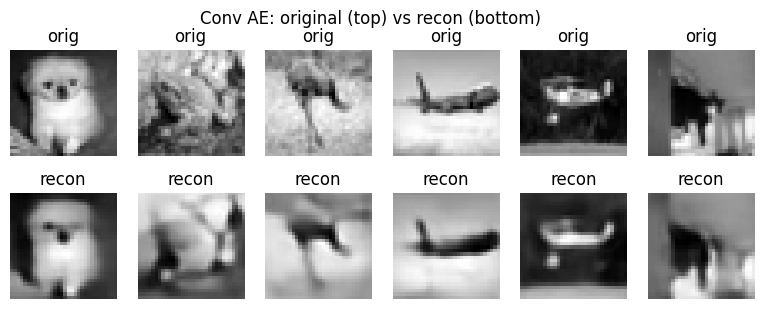

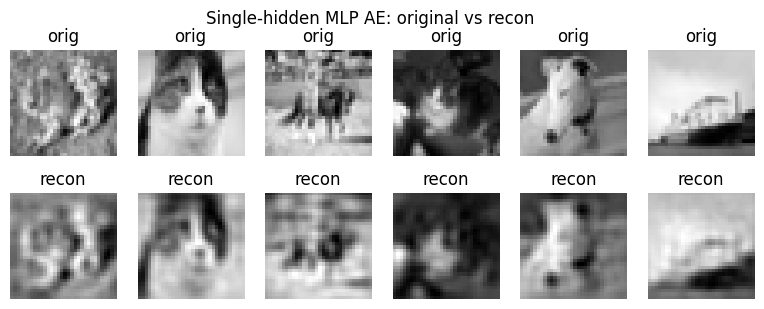

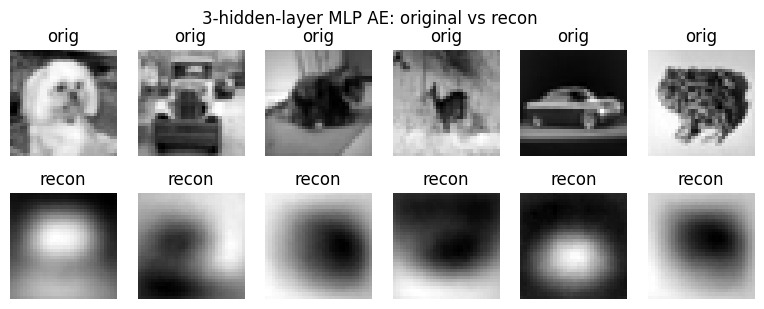

In [4]:
X_train_img = X_train_scaled.reshape(-1, h, w, 1)
X_test_img  = X_test_scaled.reshape(-1, h, w, 1)

print("Train / Test shapes (flat):", X_train_scaled.shape, X_test_scaled.shape)
print("Train / Test shapes (img):", X_train_img.shape, X_test_img.shape)

# PCA from Task 1
K = results_full['K']


# Deep Convolutional Autoencoder
def build_conv_autoencoder(input_shape=(h,w,1), latent_dim=K):
    inp = keras.Input(shape=input_shape)
    x = layers.Conv2D(32, (3,3), strides=1, padding='same', activation='relu')(inp)  # 32x32x32
    x = layers.MaxPool2D((2,2), padding='same')(x)  # 16x16x32
    x = layers.Conv2D(64, (3,3), strides=1, padding='same', activation='relu')(x)   # 16x16x64
    x = layers.MaxPool2D((2,2), padding='same')(x)  # 8x8x64
    x = layers.Conv2D(128, (3,3), strides=1, padding='same', activation='relu')(x)  # 8x8x128
    x = layers.MaxPool2D((2,2), padding='same')(x)  # 4x4x128
    x = layers.Flatten()(x)
    z = layers.Dense(latent_dim, name='latent')(x)  # linear latent
    # Decoder
    x = layers.Dense(4*4*128, activation='relu')(z)
    x = layers.Reshape((4,4,128))(x)
    x = layers.UpSampling2D((2,2))(x)  # 8x8x128
    x = layers.Conv2D(128, (3,3), padding='same', activation='relu')(x)
    x = layers.UpSampling2D((2,2))(x)  # 16x16x128
    x = layers.Conv2D(64, (3,3), padding='same', activation='relu')(x)
    x = layers.UpSampling2D((2,2))(x)  # 32x32x64
    x = layers.Conv2D(32, (3,3), padding='same', activation='relu')(x)
    # Final conv to single-channel linear output
    x = layers.Conv2D(1, (3,3), padding='same', activation=None)(x)  # linear
    model = keras.Model(inputs=inp, outputs=x, name='conv_autoencoder')
    return model

conv_ae = build_conv_autoencoder(input_shape=(h,w,1), latent_dim=K)
conv_ae.summary()

# Compile
conv_ae.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse')

# Train conv AE
epochs_conv = 30
batch_size = 256
history_conv = conv_ae.fit(
    X_train_img, X_train_img,
    validation_data=(X_test_img, X_test_img),
    epochs=epochs_conv, batch_size=batch_size, verbose=2
)

# Compute reconstruction on test set (flattened for MSE calculation)
X_test_recon_conv = conv_ae.predict(X_test_img, batch_size=256)
mse_conv = np.mean((X_test_img.reshape(len(X_test_img), -1) - X_test_recon_conv.reshape(len(X_test_recon_conv), -1))**2)
print(f"[Conv AE] Test reconstruction MSE: {mse_conv:.6f}")

# Single-hidden-layer MLP Autoencoder with encoder sigmoid activation decoder linear activation
def build_single_hidden_mlp(input_dim=input_dim, latent_dim=K):
    inp = keras.Input(shape=(input_dim,))
    # Sigmoid encoder to K
    z = layers.Dense(latent_dim, activation='sigmoid', name='latent')(inp)
    # Linear decoder
    x_hat = layers.Dense(input_dim, activation=None)(z)
    model = keras.Model(inputs=inp, outputs=x_hat, name='single_hidden_mlp_ae')
    return model

mlp1 = build_single_hidden_mlp(input_dim=input_dim, latent_dim=K)
mlp1.summary()
mlp1.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse')

# Train on flattened standardized data
epochs_mlp = 50
history_mlp1 = mlp1.fit(
    X_train_scaled, X_train_scaled,
    validation_data=(X_test_scaled, X_test_scaled),
    epochs=epochs_mlp, batch_size=256, verbose=2
)

# Evaluate MSE on test set
X_test_recon_mlp1 = mlp1.predict(X_test_scaled, batch_size=256)
mse_mlp1 = np.mean((X_test_scaled - X_test_recon_mlp1)**2)
print(f"[Single-hidden MLP AE] Test reconstruction MSE: {mse_mlp1:.6f}")

# 3-hidden-layer MLP Autoencoder
#    Implementation: encoder: Dense(h1, act='sigmoid') -> Dense(h2, act='sigmoid') -> Dense(latent=K, linear)
#    Decoder mirrors encoder and final layer activation is linear.

import math
h_each = int(math.ceil(K / 3.0))
h1 = h2 = h_each
print("3-hidden-layer MLP AE config: h1 = h2 = approx K/3 ->", h1, h2, "latent K =", K)

def build_three_hidden_mlp(input_dim=input_dim, h1=h1, h2=h2, latent_dim=K):
    inp = keras.Input(shape=(input_dim,))
    x = layers.Dense(h1, activation='sigmoid')(inp)
    x = layers.Dense(h2, activation='sigmoid')(x)
    z = layers.Dense(latent_dim, activation='sigmoid', name='latent')(x)  # use sigmoid at autoencoder
    x = layers.Dense(h2, activation='sigmoid')(z)
    x = layers.Dense(h1, activation='sigmoid')(x)
    x_hat = layers.Dense(input_dim, activation=None)(x)  # final linear decoder
    model = keras.Model(inputs=inp, outputs=x_hat, name='three_hidden_mlp_ae')
    return model

mlp3 = build_three_hidden_mlp(input_dim=input_dim, h1=h1, h2=h2, latent_dim=K)
mlp3.summary()
mlp3.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse')

# Train
epochs_mlp3 = 50
history_mlp3 = mlp3.fit(
    X_train_scaled, X_train_scaled,
    validation_data=(X_test_scaled, X_test_scaled),
    epochs=epochs_mlp3, batch_size=256, verbose=2
)

# Evaluate
X_test_recon_mlp3 = mlp3.predict(X_test_scaled, batch_size=256)
mse_mlp3 = np.mean((X_test_scaled - X_test_recon_mlp3)**2)
print(f"[3-hidden-layer MLP AE] Test reconstruction MSE: {mse_mlp3:.6f}")

# Results
print("\n=== Reconstruction MSE (test set) ===")
print(f"Conv AE (deep conv)               : {mse_conv:.6f}")
print(f"Single-hidden MLP (sigmoid->linear): {mse_mlp1:.6f}")
print(f"3-hidden-layer MLP (sigmoid, final linear): {mse_mlp3:.6f}")

# original vs reconstructions (grayscale)
def show_reconstructions(original_flat, recon_flat, n=8, title_prefix=""):
    idx = np.random.choice(len(original_flat), size=n, replace=False)
    fig, axes = plt.subplots(2, n, figsize=(n*1.6, 3.4))
    for i, j in enumerate(idx):
        orig = original_flat[j].reshape(h, w)
        rec  = recon_flat[j].reshape(h, w)
        # un-standardize for display
        axes[0, i].imshow((orig - orig.min()) / (orig.max() - orig.min() + 1e-12), cmap='gray')
        axes[0, i].axis('off')
        axes[0, i].set_title("orig")
        axes[1, i].imshow((rec - rec.min()) / (rec.max() - rec.min() + 1e-12), cmap='gray')
        axes[1, i].axis('off')
        axes[1, i].set_title("recon")
    plt.suptitle(title_prefix)
    plt.show()

# For conv ae, use image-shaped outputs; convert to flattened comparable format (same scaling)
show_reconstructions(X_test_scaled, X_test_recon_conv.reshape(len(X_test_recon_conv), -1), n=6, title_prefix="Conv AE: original (top) vs recon (bottom)")
show_reconstructions(X_test_scaled, X_test_recon_mlp1, n=6, title_prefix="Single-hidden MLP AE: original vs recon")
show_reconstructions(X_test_scaled, X_test_recon_mlp3, n=6, title_prefix="3-hidden-layer MLP AE: original vs recon")


### Task 4: MNIST -> Conv Autoencoder -> extract features -> 7-output MLP (7-seg LED) -> confusion matrix

MNIST shapes: (60000, 28, 28, 1) (10000, 28, 28, 1) Labels: [0 1 2 3 4 5 6 7 8 9]


Model: "conv_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3136)           │       203,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 28, 28, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 479,105 (1.83 MB)

 Trainable params: 479,105 (1.83 MB)

...

Epoch 1/25


2025-12-07 09:07:34.596913: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_299', 8 bytes spill stores, 8 bytes spill loads



235/235 - 12s - 52ms/step - loss: 0.0209 - val_loss: 0.0073 - learning_rate: 0.0010
Epoch 2/25
235/235 - 3s - 12ms/step - loss: 0.0060 - val_loss: 0.0049 - learning_rate: 0.0010
Epoch 3/25
235/235 - 3s - 12ms/step - loss: 0.0045 - val_loss: 0.0040 - learning_rate: 0.0010
Epoch 4/25
235/235 - 3s - 12ms/step - loss: 0.0039 - val_loss: 0.0036 - learning_rate: 0.0010
Epoch 5/25
235/235 - 3s - 14ms/step - loss: 0.0035 - val_loss: 0.0033 - learning_rate: 0.0010
Epoch 6/25
235/235 - 3s - 13ms/step - loss: 0.0031 - val_loss: 0.0030 - learning_rate: 0.0010
Epoch 7/25
235/235 - 5s - 23ms/step - loss: 0.0029 - val_loss: 0.0029 - learning_rate: 0.0010
Epoch 8/25
235/235 - 3s - 13ms/step - loss: 0.0028 - val_loss: 0.0027 - learning_rate: 0.0010
Epoch 9/25
235/235 - 3s - 14ms/step - loss: 0.0026 - val_loss: 0.0026 - learning_rate: 0.0010
Epoch 10/25
235/235 - 3s - 14ms/step - loss: 0.0025 - val_loss: 0.0027 - learning_rate: 0.0010
Epoch 11/25
235/235 - 2s - 9ms/step - loss: 0.0024 - val_loss: 0.0024

2025-12-07 09:08:54.514077: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_65', 8 bytes spill stores, 8 bytes spill loads



20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step


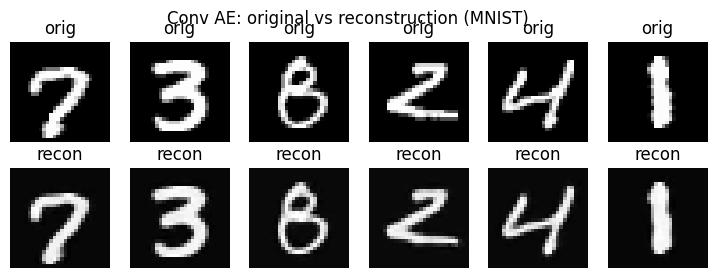

118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Latent features shapes: (60000, 64) (10000, 64)


Model: "7seg_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,031 (66.53 KB)

 Trainable params: 17,031 (66.53 KB)

...

235/235 - 12s - 52ms/step - accuracy: 0.2749 - loss: 0.2103 - val_accuracy: 0.3810 - val_loss: 0.0768 - learning_rate: 0.0010
Epoch 2/30
235/235 - 1s - 3ms/step - accuracy: 0.3742 - loss: 0.0762 - val_accuracy: 0.3746 - val_loss: 0.0492 - learning_rate: 0.0010
Epoch 3/30
235/235 - 1s - 4ms/step - accuracy: 0.3728 - loss: 0.0587 - val_accuracy: 0.3740 - val_loss: 0.0434 - learning_rate: 5.0000e-04


2025-12-07 09:09:10.826282: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-07 09:09:10.826358: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-07 09:09:11.618354: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_16', 116 bytes spill stores, 116 bytes spill loads

2025-12-07 09:09:11.691010: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning :

 1/20 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step

2025-12-07 09:09:12.346392: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-07 09:09:12.346447: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-07 09:09:12.956604: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_9', 4 bytes spill stores, 4 bytes spill loads

2025-12-07 09:09:13.158955: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Regi

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step
Segment 0 accuracy: 98.44%
Segment 1 accuracy: 97.57%
Segment 2 accuracy: 98.57%
Segment 3 accuracy: 97.33%
Segment 4 accuracy: 96.22%
Segment 5 accuracy: 96.66%
Segment 6 accuracy: 97.68%
Average segment accuracy: 97.50%
Digit accuracy (mapped from 7-seg predictions): 90.32%


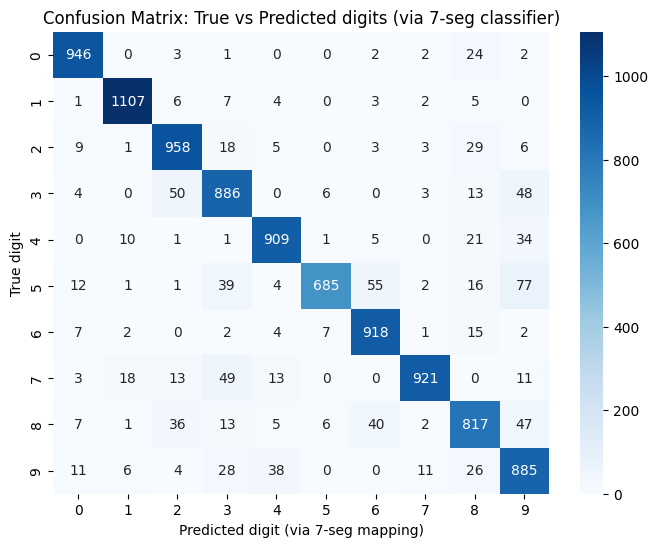

Total mismatches: 968 / 10000
True: 4  Predicted: 6  Pred seg: [1 0 1 1 1 1 1] Prob seg: [0.786 0.346 0.927 0.738 0.74  0.994 0.972]


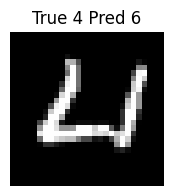

True: 5  Predicted: 4  Pred seg: [1 1 1 0 0 1 1] Prob seg: [0.662 0.638 0.997 0.315 0.017 0.791 0.65 ]


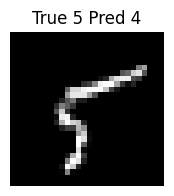

True: 3  Predicted: 2  Pred seg: [1 1 0 1 1 0 1] Prob seg: [1.    0.993 0.358 1.    0.69  0.017 0.999]


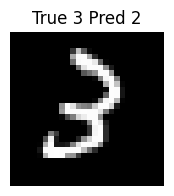

True: 9  Predicted: 3  Pred seg: [1 1 1 1 0 0 0] Prob seg: [0.995 1.    0.998 0.728 0.091 0.184 0.498]


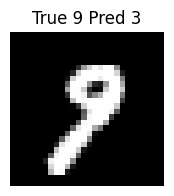

True: 2  Predicted: 8  Pred seg: [1 1 1 1 1 1 1] Prob seg: [0.999 0.989 0.677 0.994 0.982 0.854 0.978]


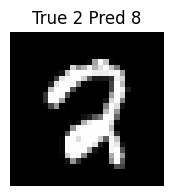

True: 4  Predicted: 8  Pred seg: [1 1 1 1 1 1 1] Prob seg: [0.531 0.945 0.994 0.598 0.686 0.996 0.996]


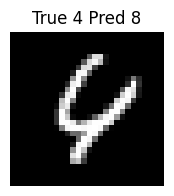

True: 7  Predicted: 3  Pred seg: [1 1 1 0 0 0 1] Prob seg: [0.524 1.    1.    0.015 0.001 0.386 0.795]


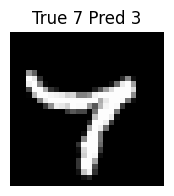

True: 0  Predicted: 2  Pred seg: [1 1 1 1 1 0 1] Prob seg: [1.    0.982 0.857 0.999 0.657 0.189 0.891]


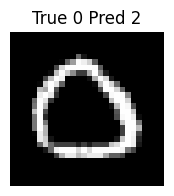

In [5]:
# Load MNIST and preprocess
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
# Normalize to [0,1]
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0

# reshape
x_train = x_train[..., np.newaxis]
x_test  = x_test[..., np.newaxis]

print("MNIST shapes:", x_train.shape, x_test.shape, "Labels:", np.unique(y_train))

# 7-segment mapping egment order:  top, top-right, bottom-right, d = bottom, e = bottom-left, f = top-left, g = middle
seg_map = {
    0: [1,1,1,1,1,1,0],
    1: [0,1,1,0,0,0,0],
    2: [1,1,0,1,1,0,1],
    3: [1,1,1,1,0,0,1],
    4: [0,1,1,0,0,1,1],
    5: [1,0,1,1,0,1,1],
    6: [1,0,1,1,1,1,1],
    7: [1,1,1,0,0,0,0],
    8: [1,1,1,1,1,1,1],
    9: [1,1,1,1,0,1,1],
}
# Precompute arrays
seg_map_arr = {d: np.array(bits, dtype=np.int32) for d,bits in seg_map.items()}
# For quick reverse lookup: map tuple(bits) -> digit
seg_tuple_to_digit = {tuple(v.tolist()): k for k,v in seg_map_arr.items()}

# Build ground-truth 7-bit labels for MNIST digits
y_train_seg = np.array([seg_map_arr[int(d)] for d in y_train])
y_test_seg  = np.array([seg_map_arr[int(d)] for d in y_test])

# Build a small conv autoencoder and train (encoder -> latent features)
input_shape = x_train.shape[1:] 
latent_dim = 64   # set latent dimension

def build_conv_autoencoder(input_shape=(28,28,1), latent_dim=64):
    inp = keras.Input(shape=input_shape)
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(inp)
    x = layers.MaxPool2D(2, padding='same')(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.MaxPool2D(2, padding='same')(x)
    x = layers.Flatten()(x)
    z = layers.Dense(latent_dim, name='latent')(x)  # linear latent
    # decoder
    x = layers.Dense(7*7*64, activation='relu')(z)
    x = layers.Reshape((7,7,64))(x)
    x = layers.UpSampling2D(2)(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.UpSampling2D(2)(x)
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    out = layers.Conv2D(1, 3, padding='same', activation=None)(x)  # linear output
    model = keras.Model(inputs=inp, outputs=out, name='conv_autoencoder')
    # encoder model separately
    encoder = keras.Model(inputs=inp, outputs=z, name='encoder')
    return model, encoder

conv_ae, encoder = build_conv_autoencoder(input_shape=input_shape, latent_dim=latent_dim)
conv_ae.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse')
conv_ae.summary()

# Train with early stopping to save time
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)
]
history = conv_ae.fit(
    x_train, x_train,
    validation_data=(x_test, x_test),
    epochs=25,
    batch_size=256,
    callbacks=callbacks,
    verbose=2
)

# show a few reconstructions
def show_recons(orig, recon, n=6, title="Reconstructions"):
    idx = np.random.choice(len(orig), size=n, replace=False)
    fig, axes = plt.subplots(2, n, figsize=(n*1.5, 3))
    for i,k in enumerate(idx):
        axes[0,i].imshow(orig[k].squeeze(), cmap='gray'); axes[0,i].axis('off'); axes[0,i].set_title("orig")
        axes[1,i].imshow(recon[k].squeeze(), cmap='gray'); axes[1,i].axis('off'); axes[1,i].set_title("recon")
    plt.suptitle(title); plt.show()

x_test_recon = conv_ae.predict(x_test, batch_size=512)
show_recons(x_test, x_test_recon, n=6, title="Conv AE: original vs reconstruction (MNIST)")

# Extract latent features for train & test
Z_train = encoder.predict(x_train, batch_size=512)
Z_test  = encoder.predict(x_test,  batch_size=512)
print("Latent features shapes:", Z_train.shape, Z_test.shape)

# Build MLP classifier with 7 outputs (sigmoid)
def build_7seg_mlp(input_dim, hidden=128):
    inp = keras.Input(shape=(input_dim,))
    x = layers.Dense(hidden, activation='relu')(inp)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(hidden//2, activation='relu')(x)
    out = layers.Dense(7, activation='sigmoid')(x)  # 7 outputs, sigmoid for multi-label
    model = keras.Model(inputs=inp, outputs=out, name='7seg_mlp')
    return model

mlp_7seg = build_7seg_mlp(Z_train.shape[1], hidden=128)
mlp_7seg.compile(optimizer=keras.optimizers.Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])
mlp_7seg.summary()

# Train the MLP on latent features to predict the 7-bit vectors
history_mlp = mlp_7seg.fit(
    Z_train, y_train_seg,
    validation_data=(Z_test, y_test_seg),
    epochs=30,
    batch_size=256,
    callbacks=callbacks,
    verbose=2
)

# Inference: predict 7 segments on test set, then map to digit
y_prob_seg = mlp_7seg.predict(Z_test, batch_size=512) 
y_pred_seg_bin = (y_prob_seg >= 0.5).astype(int)

# Map 7-bit pattern to digit:
def seg_bits_to_digit(bits_row):
    tup = tuple(int(b) for b in bits_row.tolist())
    if tup in seg_tuple_to_digit:
        return seg_tuple_to_digit[tup]
    # else pick nearest by Hamming distance:
    best_d, best_hd = None, 999
    for d, patt in seg_map_arr.items():
        hd = np.sum(np.abs(patt - bits_row))
        if hd < best_hd:
            best_hd = hd; best_d = d
    return int(best_d)

# Apply mapping for all test samples
y_pred_digits = np.array([seg_bits_to_digit(row) for row in y_pred_seg_bin])
y_true_digits = y_test.copy()

# Also compute per-segment accuracy
segment_acc = (y_pred_seg_bin == y_test_seg).mean(axis=0)
for i,acc in enumerate(segment_acc):
    print(f"Segment {i} accuracy: {acc*100:.2f}%")
print("Average segment accuracy: {:.2f}%".format(segment_acc.mean()*100))

# Digit-level accuracy (after mapping)
digit_acc = accuracy_score(y_true_digits, y_pred_digits)
print("Digit accuracy (mapped from 7-seg predictions): {:.2f}%".format(digit_acc*100))

# Confusion matrix (digits) & plot
cm = confusion_matrix(y_true_digits, y_pred_digits, labels=np.arange(10))
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.arange(10), yticklabels=np.arange(10))
plt.xlabel("Predicted digit (via 7-seg mapping)")
plt.ylabel("True digit")
plt.title("Confusion Matrix: True vs Predicted digits (via 7-seg classifier)")
plt.show()

# Also show a few examples where mapping failed 
mismatch_idx = np.where(y_true_digits != y_pred_digits)[0]
print(f"Total mismatches: {len(mismatch_idx)} / {len(y_test)}")
for i in mismatch_idx[:8]:
    print("True:", y_true_digits[i], " Predicted:", y_pred_digits[i], " Pred seg:", y_pred_seg_bin[i], "Prob seg:", np.round(y_prob_seg[i],3))
    plt.figure(figsize=(2,2)); plt.imshow(x_test[i].squeeze(), cmap='gray'); plt.axis('off'); plt.title(f"True {y_true_digits[i]} Pred {y_pred_digits[i]}"); plt.show()
